

Mayuresh Vengurlekar

CMPN - B

23102B0018

In [1]:
import cv2
import numpy as np
from PIL import Image
import os

In [2]:
def text_to_binary(text):
    return ''.join([format(ord(i), '08b') for i in text])

def hide_text(image_path, text_to_hide, output_path='stego_image.png'):
    img = Image.open(image_path).convert("RGB")
    img_array = np.array(img)

    text_to_hide += '#####'
    binary_text = text_to_binary(text_to_hide)

    data_len = len(binary_text)
    img_pixels = img_array.shape[0] * img_array.shape[1] * img_array.shape[2]

    if data_len > img_pixels:
        raise ValueError("Text is too large to hide in this image.")

    data_idx = 0
    for r in range(img_array.shape[0]):
        for c in range(img_array.shape[1]):
            for channel in range(img_array.shape[2]):
                if data_idx < data_len:
                    pixel_value = img_array[r, c, channel]
                    img_array[r, c, channel] = (pixel_value & 0xFE) | int(binary_text[data_idx])
                    data_idx += 1
                else:
                    break
            if data_idx >= data_len:
                break
        if data_idx >= data_len:
            break

    stego_img = Image.fromarray(img_array)
    stego_img.save(output_path)
    print(f"Text successfully hidden in {output_path}")
    return output_path


In [3]:
def binary_to_text(binary_string):
    text = ""
    for i in range(0, len(binary_string), 8):
        byte = binary_string[i:i+8]
        text += chr(int(byte, 2))
    return text

def reveal_text(stego_image_path):
    img = Image.open(stego_image_path).convert("RGB")
    img_array = np.array(img)

    binary_data = ""
    for r in range(img_array.shape[0]):
        for c in range(img_array.shape[1]):
            for channel in range(img_array.shape[2]):
                pixel_value = img_array[r, c, channel]
                binary_data += str(pixel_value & 1)

    decoded_text = ""
    for i in range(0, len(binary_data), 8):
        if i + 8 <= len(binary_data):
            byte = binary_data[i:i+8]
            char = chr(int(byte, 2))
            if char == '#' and binary_data[i:i+40] == text_to_binary('#####'):
                break
            decoded_text += char
    return decoded_text


Original image: /content/original-zebras.bmp
Secret message: This is a top secret message hidden within the image! Do not share it!
Text successfully hidden in hidden_message_image.png

Visual Comparison:


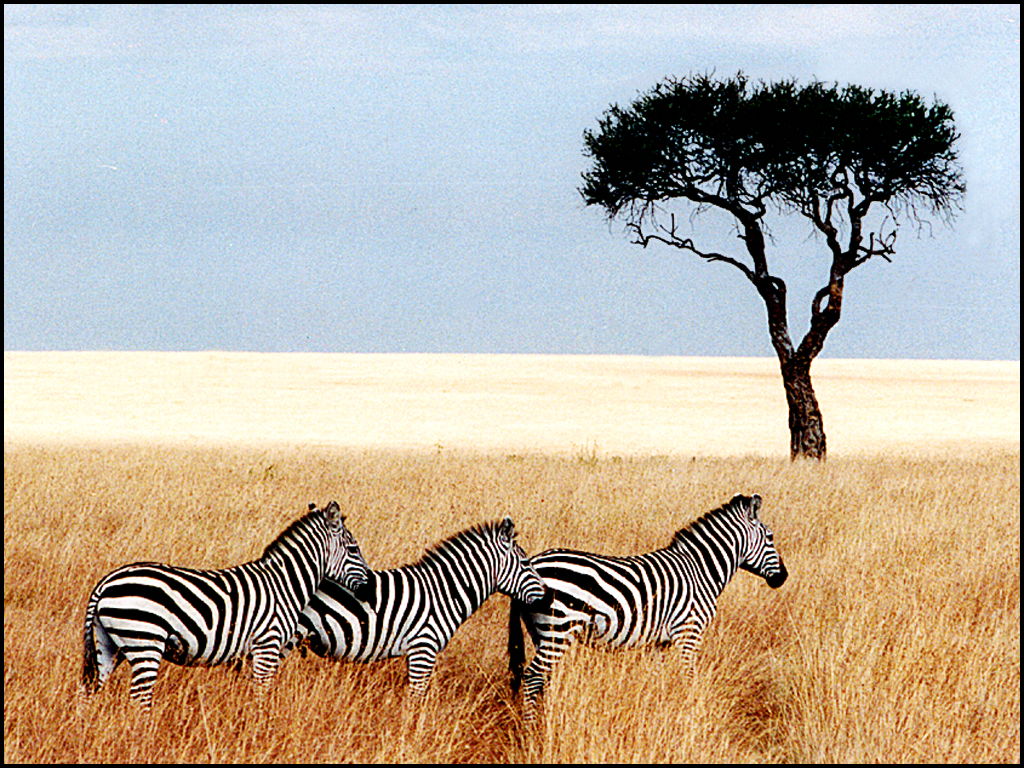

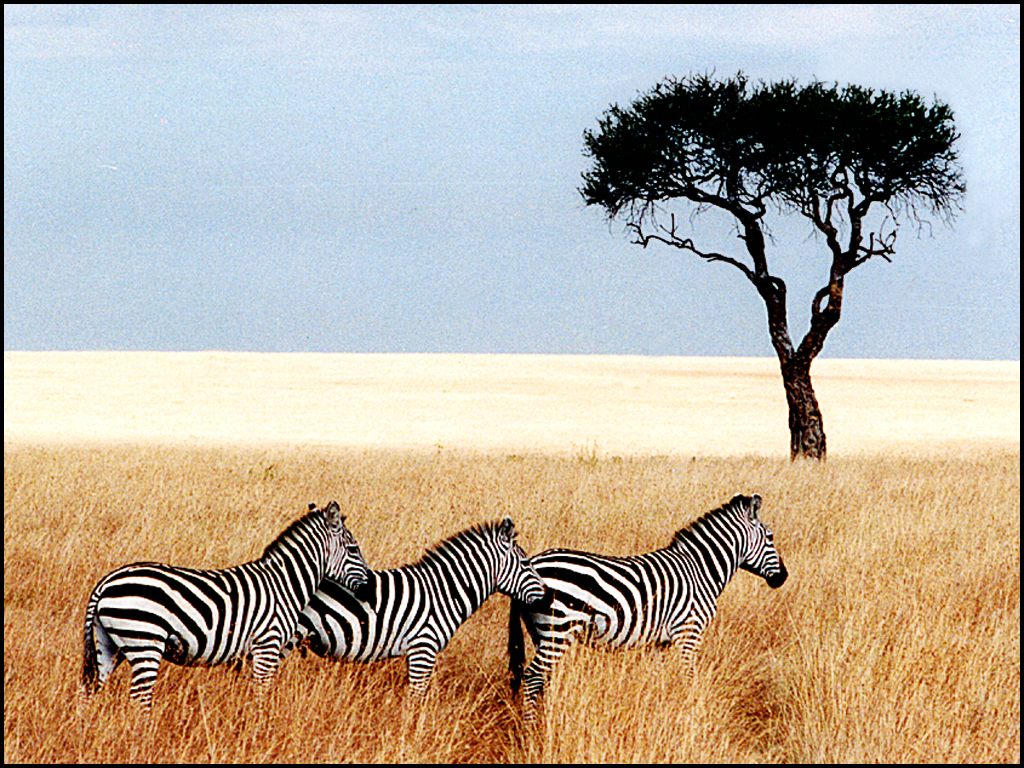


Revealed message: This is a top secret message hidden within the image! Do not share it!
Message successfully hidden and revealed with integrity!


In [4]:
image_file = '/content/original-zebras.bmp'

secret_message = "This is a top secret message hidden within the image! Do not share it!"
stego_image_output = 'hidden_message_image.png'

print(f"Original image: {image_file}")
print(f"Secret message: {secret_message}")

hide_text(image_file, secret_message, stego_image_output)

original_img = Image.open(image_file)
stego_img = Image.open(stego_image_output)

print("\nVisual Comparison:")
display(original_img)
display(stego_img)

revealed_message = reveal_text(stego_image_output)
print(f"\nRevealed message: {revealed_message}")

if secret_message == revealed_message:
    print("Message successfully hidden and revealed with integrity!")
else:
    print("There was an error in hiding/revealing the message.")


In [5]:
from math import log10, sqrt

def calculate_mse_psnr(original_image_path, stego_image_path):
    original_img = cv2.imread(original_image_path)
    stego_img = cv2.imread(stego_image_path)

    if original_img is None or stego_img is None:
        raise FileNotFoundError("One or both images not found.")

    if original_img.shape != stego_img.shape:
        raise ValueError("Images must have the same dimensions.")

    mse = np.mean((original_img - stego_img) ** 2)
    if mse == 0:
        return 0, 100

    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))

    return mse, psnr

mse, psnr = calculate_mse_psnr(image_file, stego_image_output)

print(f"\nQuantitative Analysis:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")

if psnr > 30:
    print("PSNR > 30 dB usually indicates high quality and imperceptible distortion.")
else:
    print("PSNR < 30 dB might indicate noticeable distortion, depending on context.")



Quantitative Analysis:
Mean Squared Error (MSE): 0.00
Peak Signal-to-Noise Ratio (PSNR): 87.10 dB
PSNR > 30 dB usually indicates high quality and imperceptible distortion.
